In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import os
from tqdm import tqdm

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
# Define paths
t1_dir = "/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2/partial_fit_5std"
t2_dir = "/data484_4/txia2/gwas_practice/individual_phenos/contrast_learning_mocov2_T2_5std"
n_features = 128

print(f"Loading {n_features} features from T1 and T2...")


Loading 128 features from T1 and T2...


In [3]:
# Load T1 features
t1_features = {}
for i in tqdm(range(n_features), desc="Loading T1 features"):
    file_path = os.path.join(t1_dir, f"Feature_{i}.csv")
    df = pd.read_csv(file_path, sep="\t")
    if i == 0:
        t1_data = df[['IID', f'pca_{i}']].copy()
    else:
        t1_data = t1_data.merge(df[['IID', f'pca_{i}']], on='IID', how='outer')

# Check for NA values in T1 data
na_count_t1 = t1_data.isna().sum().sum()
if na_count_t1 > 0:
    print(f"Warning: Found {na_count_t1} NA values in T1 data")
    print(f"NA values per column: {t1_data.isna().sum()[t1_data.isna().sum() > 0].to_dict()}")

print(f"T1 data shape: {t1_data.shape}")
print(f"T1 columns: {t1_data.columns.tolist()[:5]}...")


Loading T1 features: 100%|██████████| 128/128 [00:03<00:00, 38.39it/s]


NA values per column: {'pca_21': 1, 'pca_25': 8, 'pca_26': 2, 'pca_27': 22, 'pca_28': 17, 'pca_29': 7, 'pca_30': 13, 'pca_31': 2, 'pca_32': 39, 'pca_33': 5, 'pca_34': 8, 'pca_35': 2, 'pca_36': 9, 'pca_37': 9, 'pca_38': 5, 'pca_39': 6, 'pca_40': 69, 'pca_41': 11, 'pca_42': 12, 'pca_43': 8, 'pca_44': 9, 'pca_45': 8, 'pca_46': 16, 'pca_47': 13, 'pca_48': 12, 'pca_49': 34, 'pca_50': 31, 'pca_51': 18, 'pca_52': 10, 'pca_53': 11, 'pca_54': 24, 'pca_55': 24, 'pca_56': 1, 'pca_57': 18, 'pca_58': 18, 'pca_59': 9, 'pca_60': 12, 'pca_61': 1, 'pca_62': 12, 'pca_63': 12, 'pca_64': 19, 'pca_65': 8, 'pca_66': 8, 'pca_67': 6, 'pca_68': 6, 'pca_70': 17, 'pca_71': 10, 'pca_72': 4, 'pca_73': 10, 'pca_74': 22, 'pca_75': 16, 'pca_76': 12, 'pca_77': 11, 'pca_78': 11, 'pca_79': 5, 'pca_80': 10, 'pca_81': 6, 'pca_82': 11, 'pca_83': 10, 'pca_84': 13, 'pca_85': 7, 'pca_86': 24, 'pca_87': 12, 'pca_88': 19, 'pca_89': 7, 'pca_90': 16, 'pca_91': 13, 'pca_92': 21, 'pca_93': 13, 'pca_94': 29, 'pca_95': 14, 'pca_96': 

In [4]:
# Load T2 features
t2_features = {}
for i in tqdm(range(n_features), desc="Loading T2 features"):
    file_path = os.path.join(t2_dir, f"Feature_{i}.csv")
    df = pd.read_csv(file_path, sep="\t")
    if i == 0:
        t2_data = df[['IID', f'pca_{i}']].copy()
    else:
        t2_data = t2_data.merge(df[['IID', f'pca_{i}']], on='IID', how='outer')

# Check for NA values in T2 data
na_count_t2 = t2_data.isna().sum().sum()
if na_count_t2 > 0:
    print(f"Warning: Found {na_count_t2} NA values in T2 data")
    print(f"NA values per column: {t2_data.isna().sum()[t2_data.isna().sum() > 0].to_dict()}")

print(f"T2 data shape: {t2_data.shape}")
print(f"T2 columns: {t2_data.columns.tolist()[:5]}...")


Loading T2 features: 100%|██████████| 128/128 [00:01<00:00, 77.49it/s]

NA values per column: {'pca_0': 2, 'pca_7': 1, 'pca_21': 1, 'pca_25': 7, 'pca_26': 14, 'pca_27': 8, 'pca_28': 9, 'pca_29': 18, 'pca_30': 12, 'pca_31': 13, 'pca_32': 11, 'pca_33': 4, 'pca_34': 23, 'pca_35': 7, 'pca_36': 4, 'pca_37': 3, 'pca_38': 5, 'pca_39': 3, 'pca_40': 32, 'pca_41': 43, 'pca_42': 16, 'pca_43': 10, 'pca_44': 10, 'pca_45': 7, 'pca_46': 6, 'pca_47': 4, 'pca_48': 16, 'pca_49': 26, 'pca_50': 27, 'pca_51': 35, 'pca_52': 9, 'pca_53': 2, 'pca_54': 34, 'pca_55': 3, 'pca_56': 10, 'pca_57': 20, 'pca_58': 21, 'pca_59': 21, 'pca_60': 21, 'pca_61': 4, 'pca_62': 8, 'pca_63': 27, 'pca_64': 13, 'pca_65': 14, 'pca_66': 5, 'pca_67': 16, 'pca_68': 12, 'pca_69': 3, 'pca_70': 8, 'pca_71': 8, 'pca_72': 6, 'pca_73': 21, 'pca_74': 6, 'pca_75': 10, 'pca_76': 19, 'pca_77': 3, 'pca_78': 24, 'pca_79': 25, 'pca_80': 20, 'pca_81': 13, 'pca_82': 4, 'pca_83': 15, 'pca_84': 18, 'pca_85': 15, 'pca_86': 16, 'pca_87': 18, 'pca_88': 8, 'pca_89': 12, 'pca_90': 30, 'pca_91': 16, 'pca_92': 15, 'pca_93': 8, '

In [5]:
# Merge T1 and T2 data by IID
merged_data = t1_data.merge(t2_data, on='IID', how='inner', suffixes=('_T1', '_T2'))
print(f"Merged data shape: {merged_data.shape}")
print(f"Number of common samples: {len(merged_data)}")

# Check for NA values in merged data
na_count_merged = merged_data.isna().sum().sum()
if na_count_merged > 0:
    print(f"\nWarning: Found {na_count_merged} NA values in merged data")
    print(f"Removing samples with any NA values...")
    n_before = len(merged_data)
    merged_data = merged_data.dropna()
    n_after = len(merged_data)
    n_removed = n_before - n_after
    print(f"Removed {n_removed} samples with NA values ({n_before} -> {n_after})")
else:
    print("No NA values found in merged data")

# Extract feature matrices - sort columns to ensure correct order (0-127)
# Column format after merge: 'pca_0_T1', 'pca_1_T1', etc.
def extract_feature_num(col_name):
    """Extract feature number from column name like 'pca_0_T1' -> 0"""
    try:
        # Remove suffix (_T1 or _T2) and extract number
        parts = col_name.replace('_T1', '').replace('_T2', '').split('_')
        if len(parts) >= 2 and parts[1].isdigit():
            return int(parts[1])
    except:
        pass
    return 999

t1_cols = sorted([col for col in merged_data.columns if col.endswith('_T1')], 
                 key=extract_feature_num)
t2_cols = sorted([col for col in merged_data.columns if col.endswith('_T2')], 
                 key=extract_feature_num)

X_t1 = merged_data[t1_cols].values
X_t2 = merged_data[t2_cols].values

# Final check for NaN in numpy arrays (should not happen after dropna, but safety check)
if np.isnan(X_t1).any() or np.isnan(X_t2).any():
    print("Warning: NaN values detected in feature matrices after extraction")
    print(f"T1 NaN count: {np.isnan(X_t1).sum()}")
    print(f"T2 NaN count: {np.isnan(X_t2).sum()}")
    # Remove rows with any NaN
    valid_rows = ~(np.isnan(X_t1).any(axis=1) | np.isnan(X_t2).any(axis=1))
    X_t1 = X_t1[valid_rows]
    X_t2 = X_t2[valid_rows]
    merged_data = merged_data.iloc[valid_rows]
    print(f"Removed rows with NaN, new shape: {X_t1.shape}")

print(f"\nT1 feature matrix shape: {X_t1.shape}")
print(f"T2 feature matrix shape: {X_t2.shape}")
print(f"T1 feature range: [{X_t1.min():.2f}, {X_t1.max():.2f}]")
print(f"T2 feature range: [{X_t2.min():.2f}, {X_t2.max():.2f}]")
print(f"T1 columns (first 5): {t1_cols[:5]}")
print(f"T2 columns (first 5): {t2_cols[:5]}")


Merged data shape: (22985, 257)
Number of common samples: 22985

Removing samples with any NA values...
Removed 366 samples with NA values (22985 -> 22619)

T1 feature matrix shape: (22619, 128)
T2 feature matrix shape: (22619, 128)
T1 feature range: [-1335.61, 1557.88]
T2 feature range: [-1343.92, 1723.85]
T1 columns (first 5): ['pca_0_T1', 'pca_1_T1', 'pca_2_T1', 'pca_3_T1', 'pca_4_T1']
T2 columns (first 5): ['pca_0_T2', 'pca_1_T2', 'pca_2_T2', 'pca_3_T2', 'pca_4_T2']


In [6]:
# Standardize the features (important for CCA)
# Ensure no NA values before standardization
assert not np.isnan(X_t1).any(), "T1 features contain NaN values before standardization"
assert not np.isnan(X_t2).any(), "T2 features contain NaN values before standardization"

scaler_t1 = StandardScaler()
scaler_t2 = StandardScaler()

X_t1_scaled = scaler_t1.fit_transform(X_t1)
X_t2_scaled = scaler_t2.fit_transform(X_t2)

# Check for NaN after standardization (should not happen, but safety check)
if np.isnan(X_t1_scaled).any() or np.isnan(X_t2_scaled).any():
    print("Warning: NaN values detected after standardization")
    print(f"T1 scaled NaN count: {np.isnan(X_t1_scaled).sum()}")
    print(f"T2 scaled NaN count: {np.isnan(X_t2_scaled).sum()}")

print("Features standardized.")
print(f"T1 scaled - mean: {X_t1_scaled.mean(axis=0)[:5]}, std: {X_t1_scaled.std(axis=0)[:5]}")
print(f"T2 scaled - mean: {X_t2_scaled.mean(axis=0)[:5]}, std: {X_t2_scaled.std(axis=0)[:5]}")


Features standardized.
T1 scaled - mean: [-5.65443620e-18 -1.44502258e-17  2.08900004e-17 -7.53924827e-18
 -1.91622560e-17], std: [1. 1. 1. 1. 1.]
T2 scaled - mean: [1.72774439e-17 1.57067672e-17 2.76439103e-17 3.14135345e-19
 3.14135345e-18], std: [1. 1. 1. 1. 1.]


In [7]:
# Perform CCA with all components
n_components = min(128, X_t1_scaled.shape[0] - 1, X_t2_scaled.shape[0] - 1)
print(f"Performing CCA with {n_components} components...")

cca = CCA(n_components=n_components)
X_t1_c, X_t2_c = cca.fit_transform(X_t1_scaled, X_t2_scaled)

print("CCA completed!")
print(f"Canonical variates shape: {X_t1_c.shape}")


Performing CCA with 128 components...


CCA completed!
Canonical variates shape: (22619, 128)


In [8]:
# Calculate canonical correlations
canonical_correlations = []
for i in range(n_components):
    corr = np.corrcoef(X_t1_c[:, i], X_t2_c[:, i])[0, 1]
    canonical_correlations.append(corr)

canonical_correlations = np.array(canonical_correlations)

print(f"Canonical correlations (first 10): {canonical_correlations[:10]}")
print(f"Mean canonical correlation: {canonical_correlations.mean():.4f}")
print(f"Max canonical correlation: {canonical_correlations.max():.4f}")
print(f"Number of components with correlation > 0.5: {(canonical_correlations > 0.5).sum()}")
print(f"Number of components with correlation > 0.3: {(canonical_correlations > 0.3).sum()}")


Canonical correlations (first 10): [0.99723501 0.99649936 0.99668015 0.99634476 0.99520095 0.99615527
 0.99537979 0.9943159  0.99357001 0.9919515 ]
Mean canonical correlation: 0.8784
Max canonical correlation: 0.9972
Number of components with correlation > 0.5: 121
Number of components with correlation > 0.3: 124


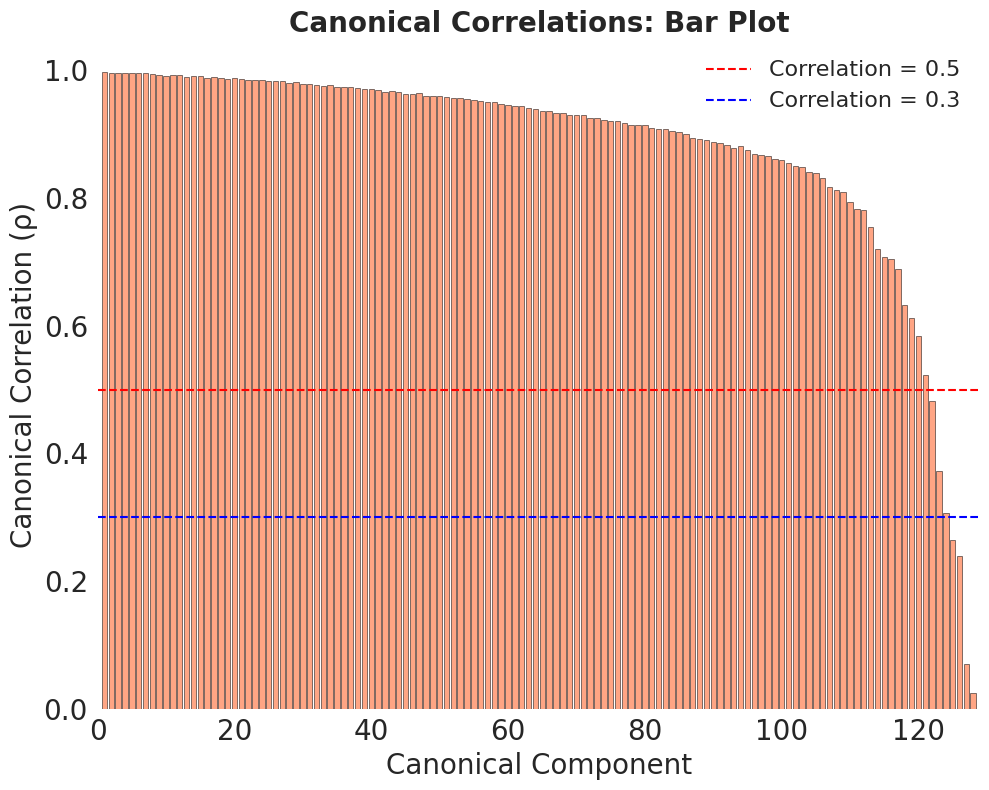


Canonical Correlations Summary:
  Total components: 128
  Mean: 0.8784
  Max: 0.9972
  Min: 0.0248
  Components with ρ > 0.5: 121
  Components with ρ > 0.3: 124

Top 10 canonical correlations:
  Rank 1: Component 1 (ρ = 0.9972)
  Rank 2: Component 3 (ρ = 0.9967)
  Rank 3: Component 2 (ρ = 0.9965)
  Rank 4: Component 4 (ρ = 0.9963)
  Rank 5: Component 6 (ρ = 0.9962)
  Rank 6: Component 7 (ρ = 0.9954)
  Rank 7: Component 5 (ρ = 0.9952)
  Rank 8: Component 8 (ρ = 0.9943)
  Rank 9: Component 9 (ρ = 0.9936)
  Rank 10: Component 11 (ρ = 0.9924)


In [9]:
# Visualize canonical correlations - Bar plot only
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(range(1, len(canonical_correlations) + 1), canonical_correlations, 
                color='coral', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(y=0.5, color='r', linestyle='--', label='Correlation = 0.5', linewidth=1.5)
ax.axhline(y=0.3, color='b', linestyle='--', label='Correlation = 0.3', linewidth=1.5)
ax.set_xlabel('Canonical Component', fontsize=20)
ax.set_ylabel('Canonical Correlation (ρ)', fontsize=20)
ax.set_title('Canonical Correlations: Bar Plot', fontsize=20, fontweight='bold')
ax.legend(fontsize=16)
ax.set_xlim(0, len(canonical_correlations) + 1)
ax.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

print(f"\nCanonical Correlations Summary:")
print(f"  Total components: {len(canonical_correlations)}")
print(f"  Mean: {canonical_correlations.mean():.4f}")
print(f"  Max: {canonical_correlations.max():.4f}")
print(f"  Min: {canonical_correlations.min():.4f}")
print(f"  Components with ρ > 0.5: {(canonical_correlations > 0.5).sum()}")
print(f"  Components with ρ > 0.3: {(canonical_correlations > 0.3).sum()}")
print(f"\nTop 10 canonical correlations:")
top_indices = np.argsort(canonical_correlations)[::-1][:10]
for i, idx in enumerate(top_indices):
    print(f"  Rank {i+1}: Component {idx+1} (ρ = {canonical_correlations[idx]:.4f})")


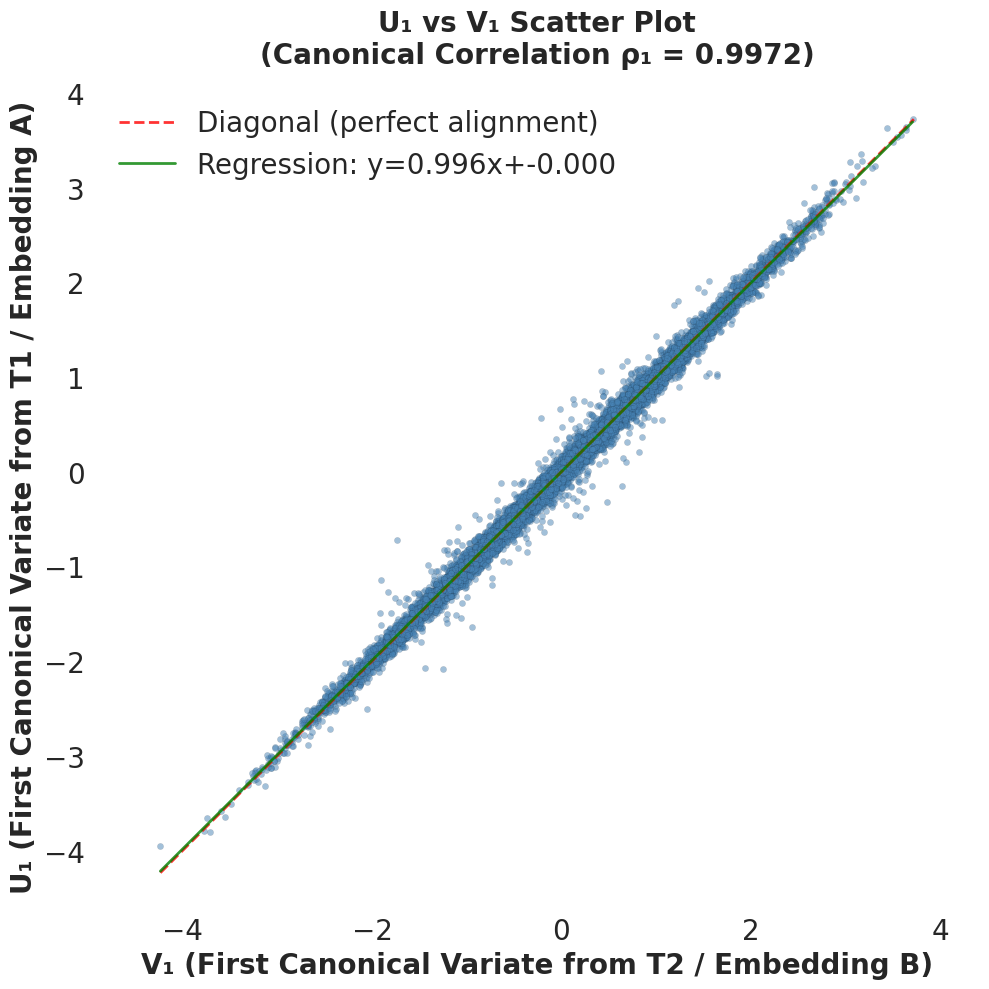

First canonical variate correlation: ρ₁ = 0.9972
If embeddings are strongly aligned, points should lie close to the diagonal.


In [10]:
# Scatter plot: U₁ vs V₁ (First canonical variate from embedding A vs embedding B)
# This is the single most common CCA visualization
# If embeddings are strongly aligned, points will lie close to the diagonal

U1 = X_t1_c[:, 0]  # First canonical variate from T1 (embedding A)
V1 = X_t2_c[:, 0]  # First canonical variate from T2 (embedding B)
rho1 = canonical_correlations[0]

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.scatter(V1, U1, alpha=0.5, s=20, c='steelblue', edgecolors='black', linewidth=0.1)

# Add diagonal line (y = x) to show perfect alignment
min_val = min(U1.min(), V1.min())
max_val = max(U1.max(), V1.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
         label=f'Diagonal (perfect alignment)', alpha=0.8)

# Add regression line
z = np.polyfit(V1, U1, 1)
p = np.poly1d(z)
x_line = np.linspace(V1.min(), V1.max(), 100)
ax.plot(x_line, p(x_line), "g-", alpha=0.8, linewidth=2, 
         label=f'Regression: y={z[0]:.3f}x+{z[1]:.3f}')

ax.set_xlabel('V₁ (First Canonical Variate from T2 / Embedding B)', fontsize=20, fontweight='bold')
ax.set_ylabel('U₁ (First Canonical Variate from T1 / Embedding A)', fontsize=20, fontweight='bold')
ax.set_title(f'U₁ vs V₁ Scatter Plot\n(Canonical Correlation ρ₁ = {rho1:.4f})', 
          fontsize=20, fontweight='bold', pad=15)
ax.legend(fontsize=20, loc='best')
ax.tick_params(labelsize=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

print(f"First canonical variate correlation: ρ₁ = {rho1:.4f}")
print(f"If embeddings are strongly aligned, points should lie close to the diagonal.")


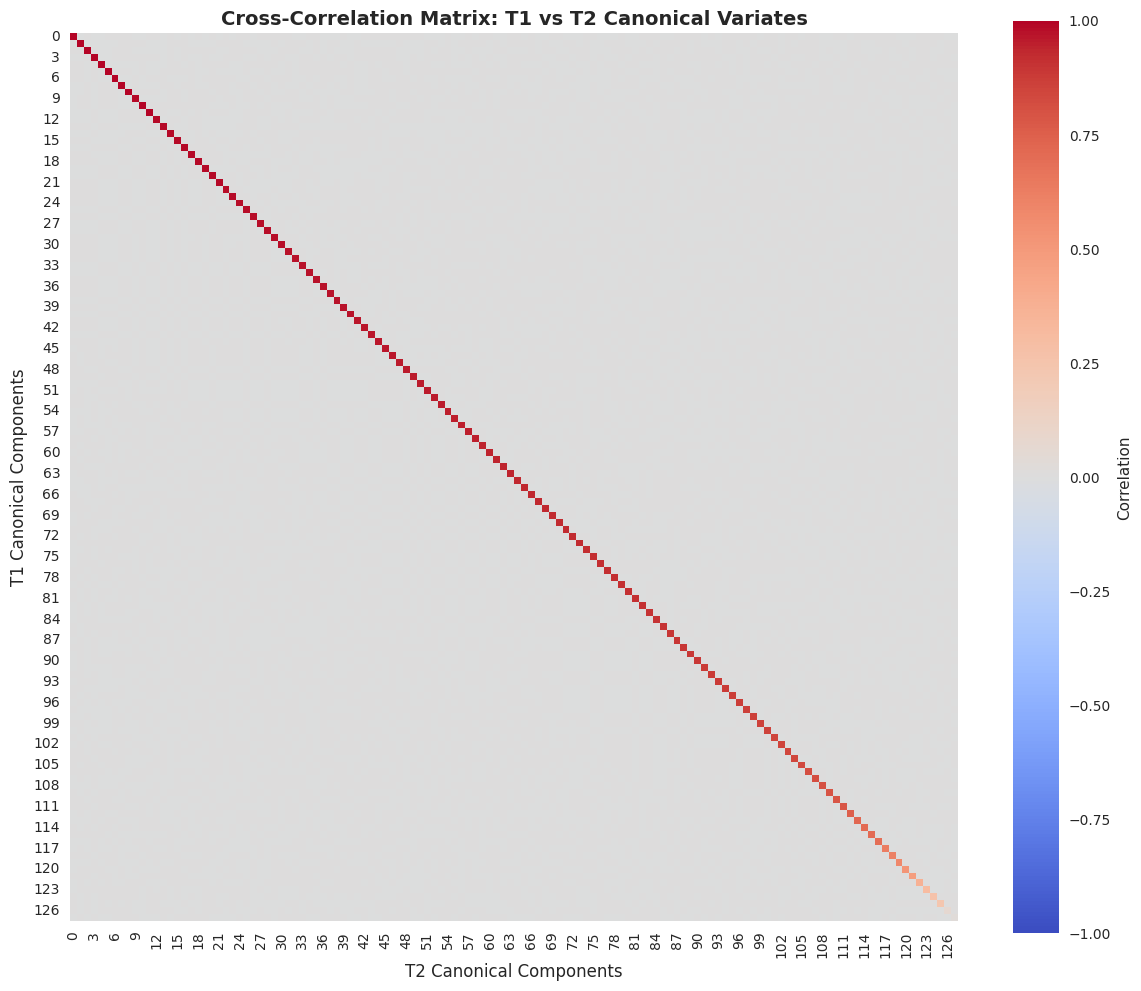


Diagonal correlations (canonical correlations):
  Mean: 0.8784
  Max: 0.9972
  Min: 0.0248


In [11]:
# Heatmap of correlations between all canonical components
correlation_matrix = np.zeros((n_components, n_components))
for i in range(n_components):
    for j in range(n_components):
        correlation_matrix[i, j] = np.corrcoef(X_t1_c[:, i], X_t2_c[:, j])[0, 1]

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
plt.xlabel('T2 Canonical Components', fontsize=12)
plt.ylabel('T1 Canonical Components', fontsize=12)
plt.title('Cross-Correlation Matrix: T1 vs T2 Canonical Variates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight diagonal (canonical correlations)
print(f"\nDiagonal correlations (canonical correlations):")
print(f"  Mean: {np.diag(correlation_matrix).mean():.4f}")
print(f"  Max: {np.diag(correlation_matrix).max():.4f}")
print(f"  Min: {np.diag(correlation_matrix).min():.4f}")


In [12]:
# Summary statistics
print("="*60)
print("CCA ANALYSIS SUMMARY")
print("="*60)
print(f"Number of samples: {len(merged_data)}")
print(f"Number of T1 features: {X_t1.shape[1]}")
print(f"Number of T2 features: {X_t2.shape[1]}")
print(f"Number of CCA components: {n_components}")
print(f"\nCanonical Correlations:")
print(f"  Mean: {canonical_correlations.mean():.4f}")
print(f"  Median: {np.median(canonical_correlations):.4f}")
print(f"  Std: {canonical_correlations.std():.4f}")
print(f"  Max: {canonical_correlations.max():.4f}")
print(f"  Min: {canonical_correlations.min():.4f}")
print(f"\nComponents with correlation > 0.5: {(canonical_correlations > 0.5).sum()}")
print(f"Components with correlation > 0.3: {(canonical_correlations > 0.3).sum()}")
print(f"Components with correlation > 0.1: {(canonical_correlations > 0.1).sum()}")
print("="*60)


CCA ANALYSIS SUMMARY
Number of samples: 22619
Number of T1 features: 128
Number of T2 features: 128
Number of CCA components: 128

Canonical Correlations:
  Mean: 0.8784
  Median: 0.9380
  Std: 0.1787
  Max: 0.9972
  Min: 0.0248

Components with correlation > 0.5: 121
Components with correlation > 0.3: 124
Components with correlation > 0.1: 126


In [13]:
# Save results
results_df = pd.DataFrame({
    'Component': range(1, n_components + 1),
    'Canonical_Correlation': canonical_correlations
})

output_path = "/data484_4/txia2/mocov2/cca_results.csv"
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

# Save canonical variates
np.save("/data484_4/txia2/mocov2/cca_t1_variates.npy", X_t1_c)
np.save("/data484_4/txia2/mocov2/cca_t2_variates.npy", X_t2_c)
print("Canonical variates saved to .npy files")


Results saved to: /data484_4/txia2/mocov2/cca_results.csv
Canonical variates saved to .npy files


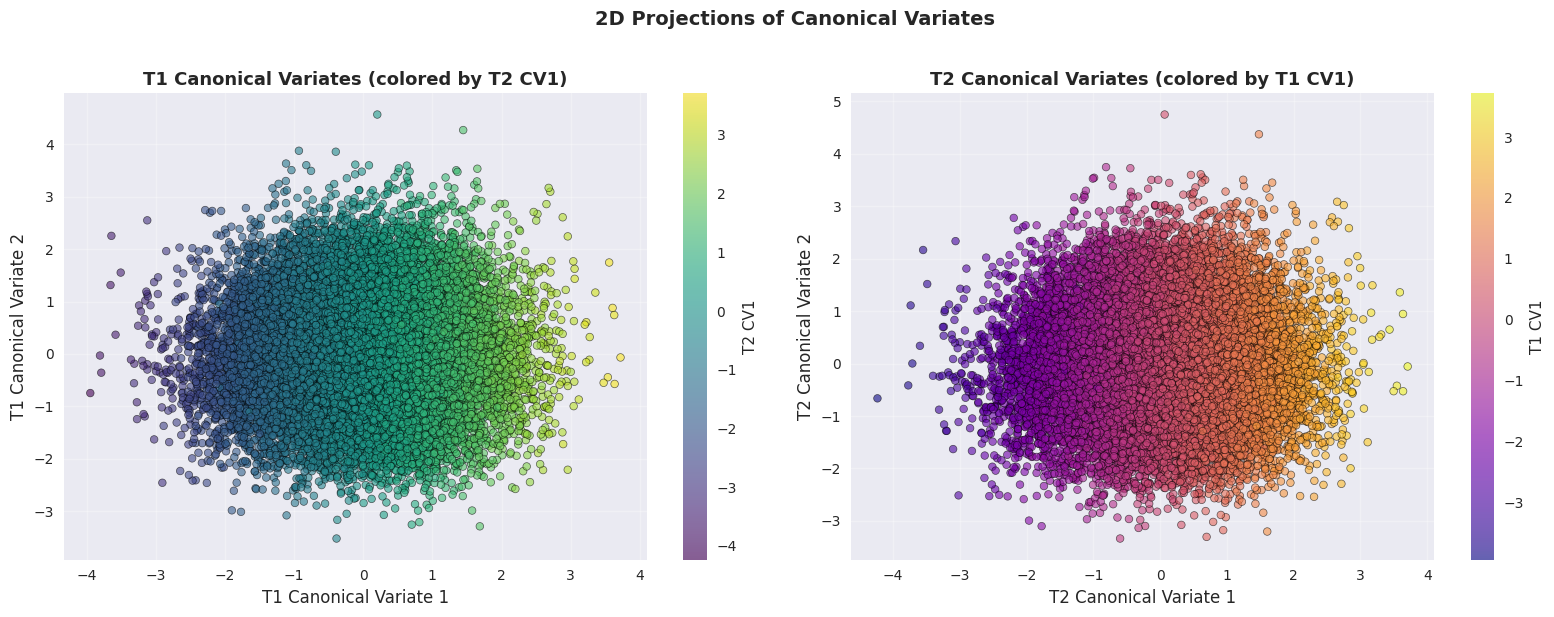

In [14]:
# 2D projection plot: First two canonical variates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T1 canonical variates (first 2 components)
ax1 = axes[0]
scatter1 = ax1.scatter(X_t1_c[:, 0], X_t1_c[:, 1], c=X_t2_c[:, 0], 
                       cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('T1 Canonical Variate 1', fontsize=12)
ax1.set_ylabel('T1 Canonical Variate 2', fontsize=12)
ax1.set_title('T1 Canonical Variates (colored by T2 CV1)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='T2 CV1')

# Plot 2: T2 canonical variates (first 2 components)
ax2 = axes[1]
scatter2 = ax2.scatter(X_t2_c[:, 0], X_t2_c[:, 1], c=X_t1_c[:, 0], 
                       cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('T2 Canonical Variate 1', fontsize=12)
ax2.set_ylabel('T2 Canonical Variate 2', fontsize=12)
ax2.set_title('T2 Canonical Variates (colored by T1 CV1)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='T1 CV1')

plt.suptitle('2D Projections of Canonical Variates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
